Implementation of Neural optimal stopping boundary, A. Max Reppen and H. Mete Soner and Valentin Tissot-Daguette

In [108]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

In [109]:
DEBUG = 0 #0, 1, 2

In [110]:
# --- Network definition ---
class StoppingBoundaryNet(nn.Module):
    def __init__(self, latent_dim, bias_init):
        super().__init__()
        hidden_units = 20 + latent_dim
        self.dense1 = nn.Linear(1 + latent_dim, hidden_units)  #1 + latent_dim for t and xi
        self.dense2 = nn.Linear(hidden_units, hidden_units)
        self.out_dense = nn.Linear(hidden_units, 1, bias=False)
        self.bias = nn.Parameter(torch.tensor([bias_init], dtype=torch.float32))

    def forward(self, t, xi):
        """"
        Args:
            - xi is a representation of the state variable x (e.g., the stock price). Shape: (B, latent_dim)
            - t is the time at which the stopping boundary is evaluated. Shape: (B, 1)
        Return:
            - the value of the stopping boundary at time t for the given state xi
              The output is a tensor of shape (B, 1), where B is the batch size.
        """
        x = torch.cat([t, xi], dim=1)
        x = F.relu(self.dense1(x))
        x = F.relu(self.dense2(x))
        return F.relu(self.out_dense(x) + self.bias)
    

class StoppingBoundaryNetForceEnd(nn.Module):
    def __init__(self, latent_dim, bias_init, T, K):
        super().__init__()
        self.T = T
        self.K = K
        hidden_units = 20 + latent_dim
        self.dense1 = nn.Linear(1 + latent_dim, hidden_units)  #1 + latent_dim for t and xi
        self.dense2 = nn.Linear(hidden_units, hidden_units)
        self.out_dense = nn.Linear(hidden_units, 1, bias=False)
        self.bias = nn.Parameter(torch.tensor([bias_init], dtype=torch.float32))

    def forward(self, t, xi):
        x = torch.cat([t, xi], dim=1)
        x = F.relu(self.dense1(x))
        x = F.relu(self.dense2(x))
        # print()
        # print(f"self.out_dense(x):", end=' ')
        # for i in range(len(self.out_dense(x))):
        #     print(self.out_dense(x)[i], end=' ')
        # print(f"self.bias: {self.bias.item()}")  
        X = self.out_dense(x) + self.bias #remove the ReLU here otherwise we cannot have negative values

        
        # print("\ninitial X", end=' ')
        # for i in range(len(X)):
        #     print(X[i], end=' ')
        # print()

        # Force the end value to be K at the last time step
        X = (self.T - t) * X + self.K * torch.ones_like(t)

        # print("self.T -t", end=' ')
        # for i in range(len(self.T - t)):
        #     print(self.T - t[i], end=' ')

        
        # print()
        # print("X", end=' ')
        # for i in range(len(X)):
        #     print(X[i], end=' ')

        return X

In [111]:
def compute_price(model, simulated_paths, K):
    """Compute the price of the option using the learned stopping boundary and simulated paths.
    
    Args:
        model: Trained neural network model
        simulated_paths: Tuple containing (paths, Z)
        K: Strike price
    """
    model.eval()

    paths, _ = simulated_paths  # Unpack the tuple (paths, Z)

    if isinstance(paths, torch.Tensor):
        paths = paths.numpy()

    # Compute the learned stopping boundary f(t)
    t_vals = np.array(t_grid, dtype=np.float32)
    t_tensor = torch.tensor(t_vals).reshape(-1, 1)
    xi_tensor = torch.zeros_like(t_tensor)  # Xi ≡ 0

    with torch.no_grad():
        f_vals = model(t_tensor, xi_tensor).numpy().flatten()

    # Implement optimal stopping logic
    option_values = np.zeros(paths.shape[0])

    for path_idx in range(paths.shape[0]):
        stopped = False
        for time_idx in range(len(t_grid)):
            stock_price = paths[path_idx, time_idx, 0]
            boundary_value = f_vals[time_idx]

            # Check if we should stop (stock price below boundary)
            if stock_price <= boundary_value:
                payoff = max(K - stock_price, 0)
                option_values[path_idx] = payoff * np.exp(-r * t_grid[time_idx])
                stopped = True
                break

        if not stopped:
            final_payoff = max(K - paths[path_idx, -1, 0], 0)
            option_values[path_idx] = final_payoff * np.exp(-r * t_grid[-1])

    # Price is the average of the option values
    price = np.mean(option_values)
    
    return price


In [112]:
#visualization utils
def plot_paths_with_boundary(model, simulate_paths, t_grid, K, num_paths=None, ylim=(0, 80), name=""):
    """Plot simulated stock paths along with the learned stopping boundary and strike price."""
    model.eval()

    # Step 1: Compute the learned stopping boundary f(t)
    t_vals = np.array(t_grid, dtype=np.float32)
    t_tensor = torch.tensor(t_vals).reshape(-1, 1)
    xi_tensor = torch.zeros_like(t_tensor)  #xi=0, for 1D put option, the boundary is independent of the state variable x
    with torch.no_grad():
        f_vals = model(t_tensor, xi_tensor).numpy().flatten()

    # Step 2: Simulate stock paths
    paths, _ = simulate_paths(num_paths)  # shape: (num_paths, len(t_grid), 1)

    # Plotting
    plt.figure(figsize=(10, 6))
    for i in range(num_paths):
        plt.plot(t_vals, paths[i, :, 0], color='lightblue', linewidth=1)

    # Stopping boundary
    plt.plot(t_vals, f_vals, color='red', linewidth=2, label='Stopping Boundary')

    # Strike price horizontal line
    plt.axhline(K, color='gray', linestyle='--', linewidth=1.5, label='Strike Price K')

    plt.xlabel('Time t')
    plt.ylabel('Stock Price')
    plt.title(f'Sample Stock Paths with Learned Stopping Boundary - {name}')
    plt.ylim(*ylim)
    plt.legend()
    plt.grid(True)
    plt.show()


In [113]:
def fuzzy_stop_probs(alpha, f_vals, eta, eps): #see 3.1
    d = eta * (f_vals - alpha)
    return torch.clamp((eps - d) / (2.0 * eps), min=0.0, max=1.0)


def train_step(model, optimizer, paths, t_grid, alpha_fn, Xi_fn, phi_fn, eta, eps, r, Z, force_end_value=False, K=None, T=None):
    """
    
    Args:
        - alpha_fn: coordinate function used to transform the state variable into a representation suitable for defining the stopping region
        - Xi_fn: function that returns the latent variable xi, which is used to define the stopping boundary
        - phi_fn: function that computes the payoff for the option at a given time and state
        - Z: Radon-Nikodym derivatives Z_t^λ, shape (B, len(t_grid))
    """
    if force_end_value and K is None:
        raise ValueError("K must be provided if force_end_value is True")
    if force_end_value and T is None:
        raise ValueError("T must be provided if force_end_value is True")

    model.train()
    B = paths.shape[0]
    b = torch.ones((B, 1), dtype=torch.float32)
    reward = torch.zeros((B, 1), dtype=torch.float32)

    for i, t in enumerate(t_grid): #for each time step t, compute the reward and update the value of b 
        t_tensor = torch.full((B, 1), t, dtype=torch.float32)
        #paths: shape (B, len(t_grid), 1), 1 is the number of features (e.g., stock price)
        x = paths[:, i, :] #shape (B, 1), stores the stock prices at time t for all paths
        z_lambda = Z[:, i].unsqueeze(1) 
        alpha_x = alpha_fn(x)
        xi = Xi_fn(x)  #transform the state variable x into a representation suitable for defining the stopping region

        f_val = model(t_tensor, xi)  #shape (B, 1)
                
        p = fuzzy_stop_probs(alpha_x, f_val, eta, eps)
        phi = phi_fn(t, x, r)
        reward += z_lambda * p * b * phi    #shape (B, 1)
        b = b * (1.0 - p)

    loss = -reward.mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()



def deep_erm_training(simulate_paths_fn, alpha_fn, Xi_fn, phi_fn,
                      eta, eps, bias0,
                      latent_dim,
                      batch_size, n_iters,
                      learning_rate,
                      t_grid, r, K, lambd=0, force_end_value=False, T=None):
    """
    Args:
        -K: strike price of the option (only used to compute the price during training or when force_end_value is True)
        -lambd: lambda parameter used in = importance sampling (default is 0, which means no importance sampling)
    """
    if force_end_value and K is None:
        raise ValueError("K must be provided if force_end_value is True")
    if force_end_value and T is None:
        raise ValueError("T must be provided if force_end_value is True")
    
    if force_end_value:
        model = StoppingBoundaryNetForceEnd(latent_dim, bias0, T, K)
    else:
        model = StoppingBoundaryNet(latent_dim, bias0)
        
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    t_grid = list(t_grid)
    t_vals = np.array(t_grid, dtype=np.float32)
    boundary_snapshots = {}

    if DEBUG >= 2:
        # Plot the initial stopping boundary before training
        print("Before training:")
        with torch.no_grad():
            t_tensor = torch.tensor(t_vals).reshape(-1, 1)
            xi_zero = torch.zeros((len(t_vals), 1), dtype=torch.float32)
            initial_f_vals = model(t_tensor, xi_zero).numpy().flatten()
            
            # Plot the initial boundary
            plt.figure()
            plt.plot(t_vals, initial_f_vals)
            plt.xlabel('Time t')
            plt.ylabel('Stopping boundary f(t)')
            plt.title('Initial Stopping Boundary Before Training')
            plt.show()


    losses = []
    prices = []
    t_prices = []
    with tqdm(range(n_iters), desc="Training", dynamic_ncols=True) as pbar:
        plot_paths_with_boundary(model, simulate_paths, t_grid, K, num_paths=50, ylim=(0, 80), name="Boundary initialization")
        for it in pbar:
            paths, Z = simulate_paths_fn(batch_size, lambd)
            paths = torch.tensor(paths, dtype=torch.float32)
            loss = train_step(model, optimizer, paths, t_grid,
                            alpha_fn, Xi_fn, phi_fn,
                            eta, eps, r, Z, force_end_value=force_end_value, K=K, T=T)
            losses.append(loss)
            pbar.set_postfix(loss=f"{loss:.6f}")

            if DEBUG >= 1 and it % 100 == 0:
                #print the loss every 100 iterations
                print(f"Iter {it}, Loss: {loss:.6f}")

            if it % max(n_iters//25, 1) == 0: #plot 25 snapshots of the stopping boundary
                with torch.no_grad():
                    t_tensor = torch.tensor(t_vals).reshape(-1, 1)
                    xi_zero = torch.zeros((len(t_vals), 1), dtype=torch.float32)
                    f_vals = model(t_tensor, xi_zero).numpy().flatten()
                    boundary_snapshots[it] = f_vals
            
            if it % max(n_iters//40, 1) == 0:
                # Compute the price every 40 iterations
                with torch.no_grad():
                    t_tensor = torch.tensor(t_vals).reshape(-1, 1)
                    xi_zero = torch.zeros((len(t_vals), 1), dtype=torch.float32)
                    f_vals = model(t_tensor, xi_zero).numpy().flatten()
                    simulated_paths = simulate_paths(100000, lambd)  # Simulate paths for price computation
                    price = compute_price(model, simulated_paths, K)
                    prices.append(price)
                    t_prices.append(it)

            if it % max(n_iters//30, 1) == 0 and DEBUG >= 2:
                # Plot the stopping boundary every 30 iterations
                    plt.figure()
                    plt.plot(t_vals, f_vals, label=f"iter={it}")
                    plt.xlabel("Time t")
                    plt.ylabel("Stopping boundary f(t)")
                    plt.title(f"Stopping Boundary at Iter {it}")
                    plt.show()

    # Final boundary
    with torch.no_grad():
        t_tensor = torch.tensor(t_vals).reshape(-1, 1)
        xi_zero = torch.zeros((len(t_vals), 1), dtype=torch.float32)
        f_final = model(t_tensor, xi_zero).numpy().flatten()

    # Plot the loss evolution
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(losses)), losses)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Loss Evolution During Training')
    plt.grid(True)
    plt.show()


    # Plot the stopping boundary evolution
    colors = plt.cm.viridis(np.linspace(0, 1, len(boundary_snapshots)))
    plt.figure(figsize=(10, 6))
    for (it, f_vals), color in zip(boundary_snapshots.items(), colors):
        plt.plot(t_vals, f_vals, color=color, label=f"{it}")

    plt.plot(t_vals, f_final, color="red", linewidth=2, label="final")
    plt.xlabel("Time t")
    plt.ylabel("f(t)")
    plt.title("Stopping Boundary Evolution")
    plt.legend(title="Iteration", loc="best")
    plt.grid(True)
    plt.show()

    # Plot the price evolution
    plt.figure(figsize=(10, 6))
    plt.plot(t_prices, prices, marker='o', color='blue')
    plt.xlabel('Iteration')
    plt.ylabel('Price')
    plt.title('Price Evolution During Training')
    plt.grid(True)
    plt.show()
    
    return model


def simulate_paths(B, lambd=0):
    """Simulates B paths of the underlying asset price using the Black-Scholes model
    
    dS_t = S_t(r*dt + sigma*dW_t)
    This SDE has a closed-form solution: S_t = S_0 * exp((r - 0.5 * sigma^2) * t + sigma * W_t)

    So  S_{t+Δt} = S_t * exp((r - 0.5 * sigma^2) * Δt + sigma * ΔW)
    ΔW = sqrt(Δt) * z and z ~ N(0, 1) is a standard normal sample.
    """
    S = np.zeros((B, len(t_grid), 1), dtype=np.float32)
    S[:, 0, 0] = K
    for i in range(len(t_grid) - 1):
        z = np.random.randn(B)
        S[:, i + 1, 0] = S[:, i, 0] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z) #S[:, i, 0] * (drift*dt + sigma*Wt)


    Z = torch.ones((B, len(t_grid)), dtype=torch.float32) #Not used here but to be consistent with importance sampling
    return S, Z

# Black-Scholes - 1D

In [114]:
# --- Problem setup ---
r = 0.06
sigma = 0.4
K = 40.0
T = 1.0
n_steps = 50
dt = T / n_steps

t_grid = list(np.linspace(0.0, T, n_steps + 1))

N_ITERS = 10000


## 1D  put option

### Without importance sampling

Training:   0%|          | 0/10000 [00:00<?, ?it/s]

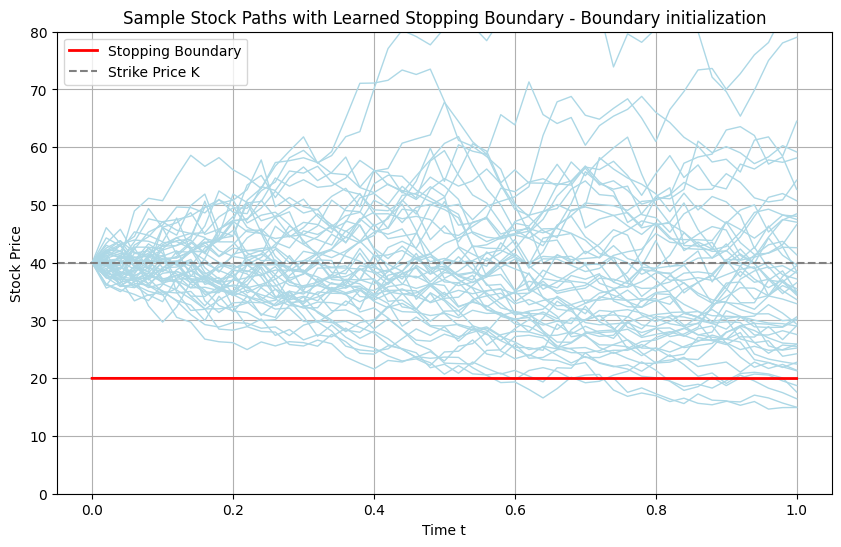

Training: 100%|██████████| 10000/10000 [15:41<00:00, 10.62it/s, loss=-5.488621]


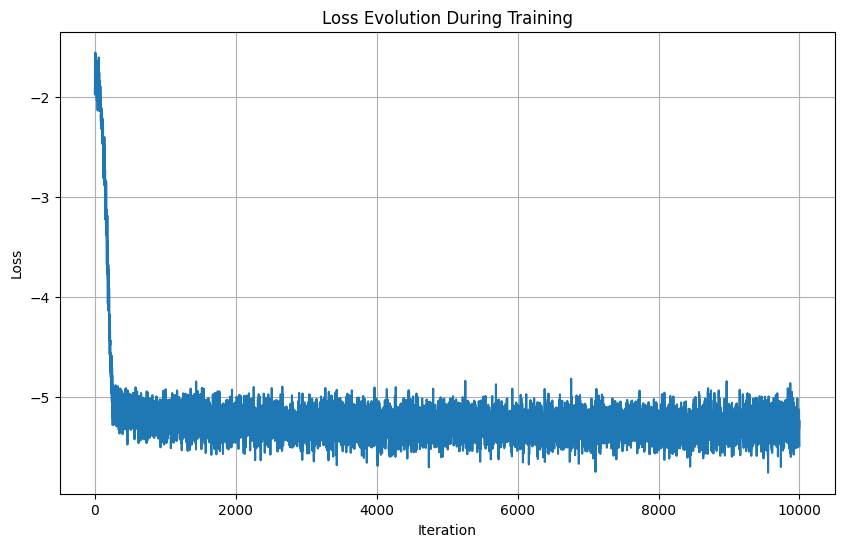

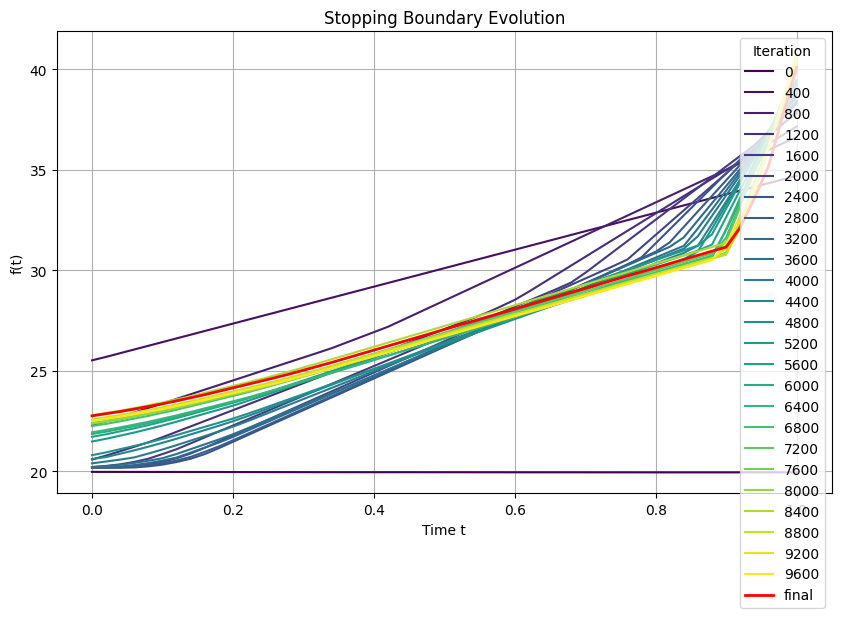

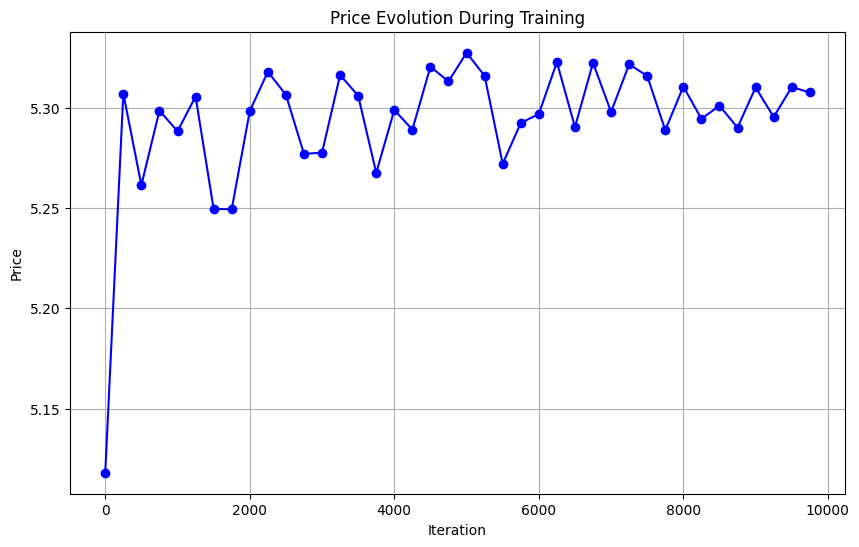

In [115]:
def simulate_paths(B, lambd=0):
    """Simulates B paths of the underlying asset price using the Black-Scholes model
    
    dS_t = S_t(r*dt + sigma*dW_t)
    This SDE has a closed-form solution: S_t = S_0 * exp((r - 0.5 * sigma^2) * t + sigma * W_t)

    So  S_{t+Δt} = S_t * exp((r - 0.5 * sigma^2) * Δt + sigma * ΔW)
    ΔW = sqrt(Δt) * z and z ~ N(0, 1) is a standard normal sample.
    """
    S = np.zeros((B, len(t_grid), 1), dtype=np.float32)
    S[:, 0, 0] = K
    for i in range(len(t_grid) - 1):
        z = np.random.randn(B)
        S[:, i + 1, 0] = S[:, i, 0] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z) #S[:, i, 0] * (drift*dt + sigma*Wt)


    Z = torch.ones((B, len(t_grid)), dtype=torch.float32) #Not used here but to be consistent with importance sampling
    return S, Z

def alpha_fn(x):
    """
    Extracts the alpha coordinate from the state variable x.

    In this implementation for 1D option, alpha(x) corresponds to the underlying asset price,
    which is assumed to be the first (and only) feature in the state vector.
    """
    return x[:, [0]]

def Xi_fn(x):
    """Stopping boundary depends only on time"""
    return torch.zeros((x.shape[0], 1), dtype=torch.float32)


def phi_fn(t, x, r):
    """Computes the payoff function for the Put Option

    Args:
        t: Current time
        x: State variable (in this case, the stock price)
        r: Risk-free interest rate
    """
    S = x[:, [0]]
    return F.relu(K - S) * np.exp(-r * t) 

# Training parameters
eta = -1
eps = K * sigma * np.sqrt(dt)
bias0 = K / 2
latent_dim = 1
batch_size = 2048
n_iters = N_ITERS
learning_rate = 1e-3

# Train
model_put = deep_erm_training(simulate_paths,
                          alpha_fn, Xi_fn, phi_fn,
                          eta, eps, bias0,
                          latent_dim,
                          batch_size, n_iters,
                          learning_rate,
                          t_grid, r, K)

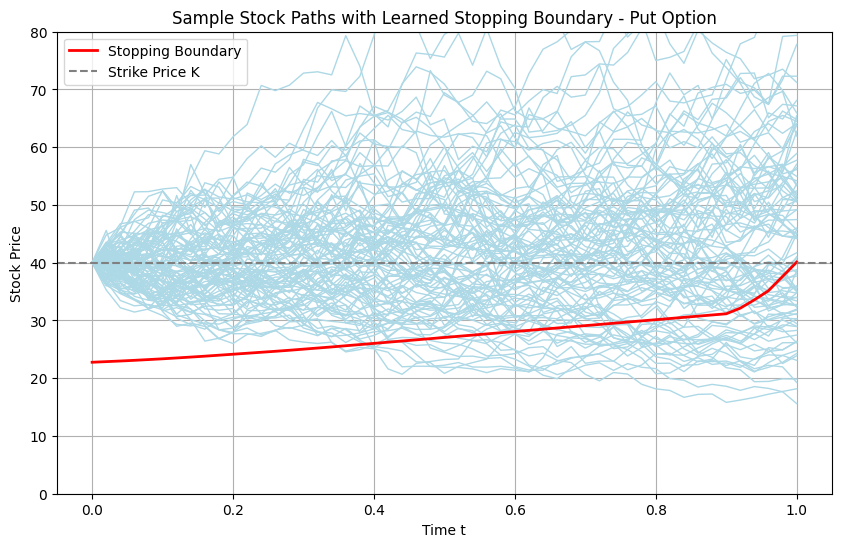

In [116]:
plot_paths_with_boundary(model_put, simulate_paths, t_grid, K, num_paths=100, name="Put Option")

In [117]:
simulated_paths_price_eval = simulate_paths(100000) 
final_price = compute_price(model_put, simulated_paths_price_eval, K)
print(f"Final price without importance sampling: {final_price:.6f}")

Final price without importance sampling: 5.313071


### Paper implementation (ie with Importance sampling)

Training:   0%|          | 0/10000 [00:00<?, ?it/s]

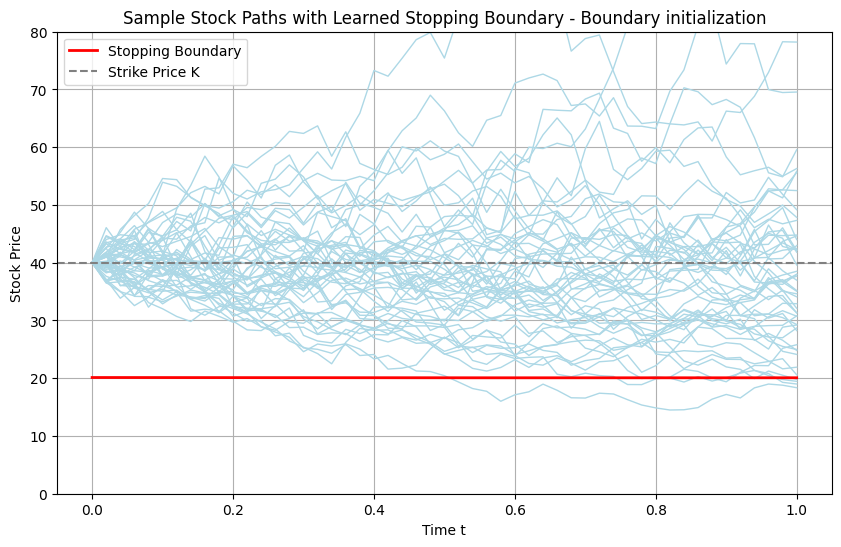

Training: 100%|██████████| 10000/10000 [15:47<00:00, 10.55it/s, loss=-5.544561]


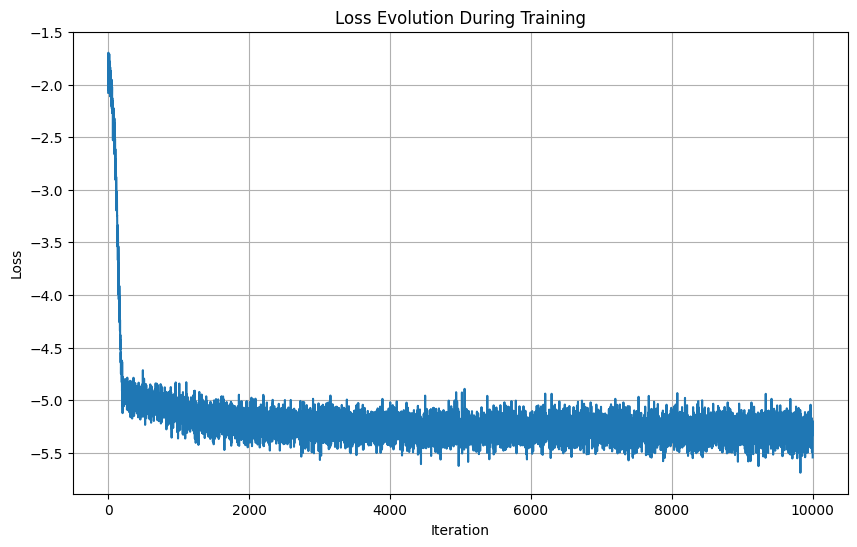

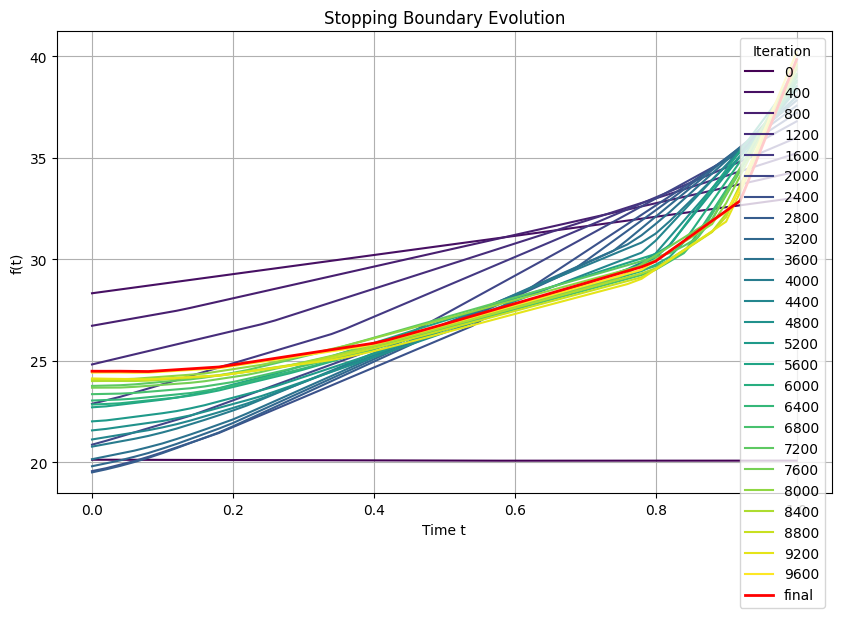

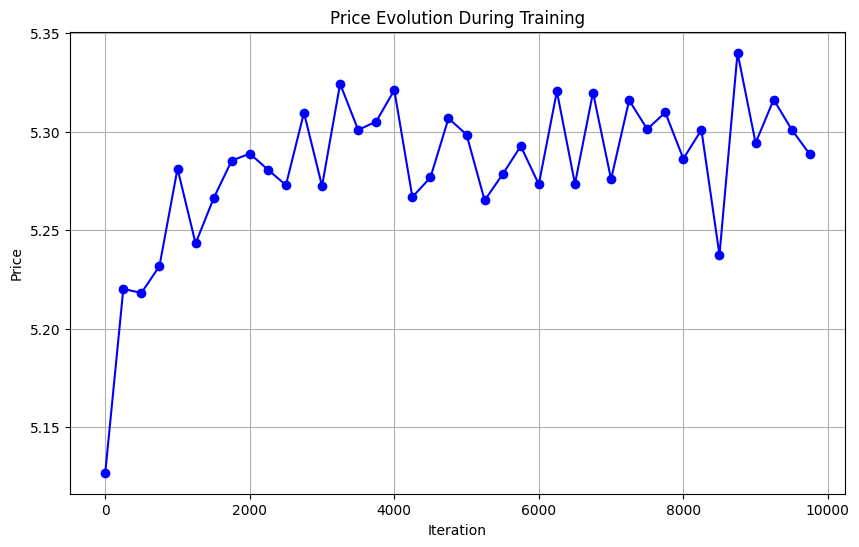

In [118]:
def simulate_paths_with_importance_sampling(B, lambd):
    """
    Simulates B asset price paths under importance sampling using the Girsanov drift adjustment,
    following the paper's formulation: dS = S * ([r - sigma * lambda] dt + sigma dW)

    Args:
        B: number of paths
        lambd: float, the constant importance sampling parameter λ

    Returns:
        S: simulated paths, shape (B, len(t_grid), 1)
        Z: Radon-Nikodym derivatives Z_t^λ, shape (B, len(t_grid))
    """
    S = np.zeros((B, len(t_grid), 1), dtype=np.float32)
    Z = np.ones((B, len(t_grid)), dtype=np.float32)
    S[:, 0, 0] = K
    W = np.zeros(B)  # cumulative Brownian motion

    for i in range(len(t_grid) - 1):
        z = np.random.randn(B)
        dW = np.sqrt(dt) * z
        W += dW

        drift_adjusted = r - sigma * lambd
        S[:, i + 1, 0] = S[:, i, 0] * np.exp((drift_adjusted - 0.5 * sigma**2)*dt + sigma*dW)

        # Radon–Nikodym derivative
        Z[:, i + 1] = np.exp(lambd*W - 0.5*lambd**2 * t_grid[i + 1])

    #convert to torch tensors
    Z = torch.tensor(Z, dtype=torch.float32)
    return S, Z



def alpha_fn(x):
    """
    Extracts the alpha coordinate from the state variable x.

    In this implementation for 1D option, alpha(x) corresponds to the underlying asset price,
    which is assumed to be the first (and only) feature in the state vector.
    """
    return x[:, [0]]

def Xi_fn(x):
    """Stopping boundary depends only on time"""
    return torch.zeros((x.shape[0], 1), dtype=torch.float32)


def phi_fn(t, x, r):
    """Computes the payoff function for the Put Option

    Args:
        t: Current time
        x: State variable (in this case, the stock price)
        r: Risk-free interest rate
    """
    S = x[:, [0]]
    return F.relu(K - S) * np.exp(-r * t) 

# Training parameters
eta = -1
eps = K * sigma * np.sqrt(dt)
bias0 = K / 2
latent_dim = 1
batch_size = 2048
learning_rate = 1e-3
lambd = 0.275
n_iters = N_ITERS

# Train
model_put_importance_sampling = deep_erm_training(simulate_paths_with_importance_sampling,
                          alpha_fn, Xi_fn, phi_fn,
                          eta, eps, bias0,
                          latent_dim,
                          batch_size, n_iters,
                          learning_rate,
                          t_grid, r, K, lambd)

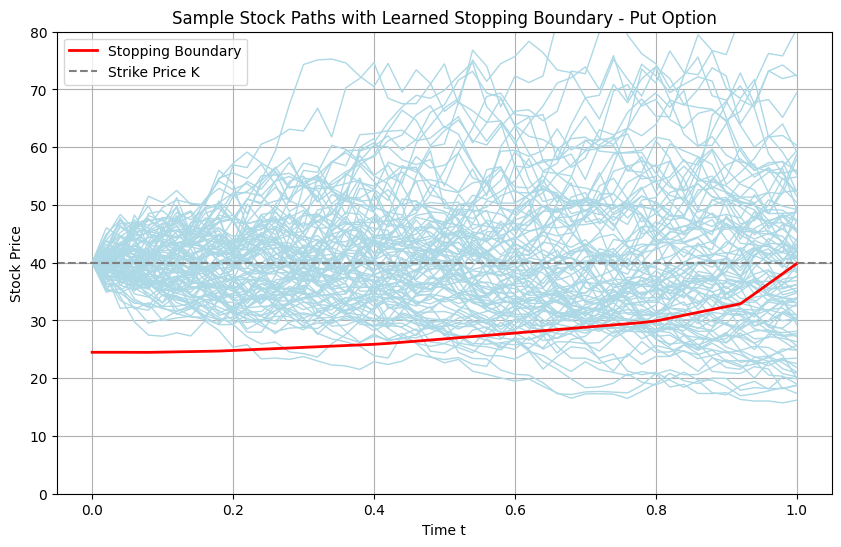

In [119]:
plot_paths_with_boundary(model_put_importance_sampling, simulate_paths, t_grid, K, num_paths=100, name="Put Option")

In [120]:
simulated_paths_price_eval = simulate_paths(100000)
final_price_with_importance_sampling_model = compute_price(model_put_importance_sampling, simulated_paths_price_eval, K)
print(f"Final price with importance sampling: {final_price_with_importance_sampling_model:.6f}")


Final price with importance sampling: 5.289956


### Sample S(0) randomly from the interval [0, 2*K]

Training:   0%|          | 0/10000 [00:00<?, ?it/s]

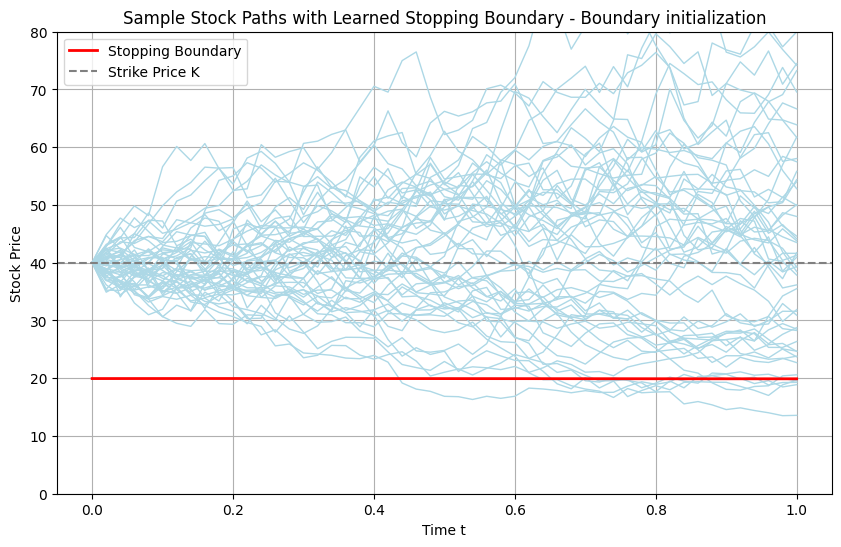

Training: 100%|██████████| 10000/10000 [15:59<00:00, 10.43it/s, loss=-11.341835]


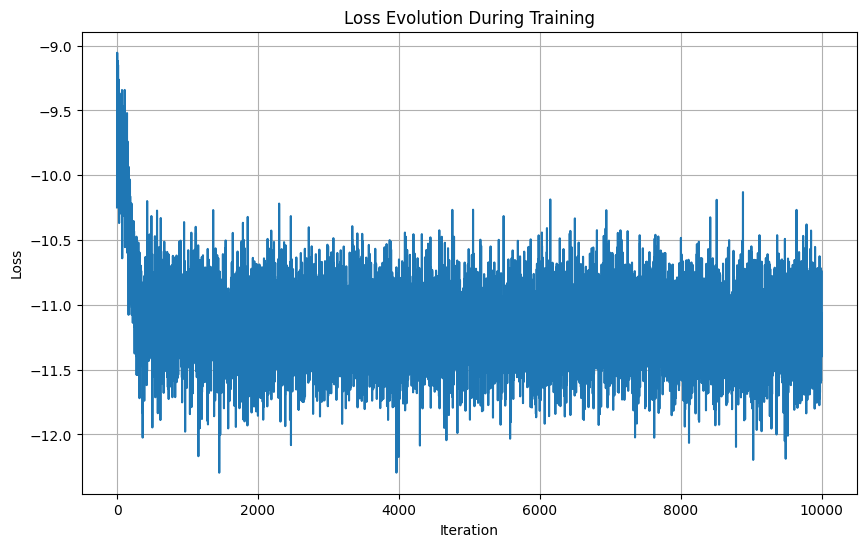

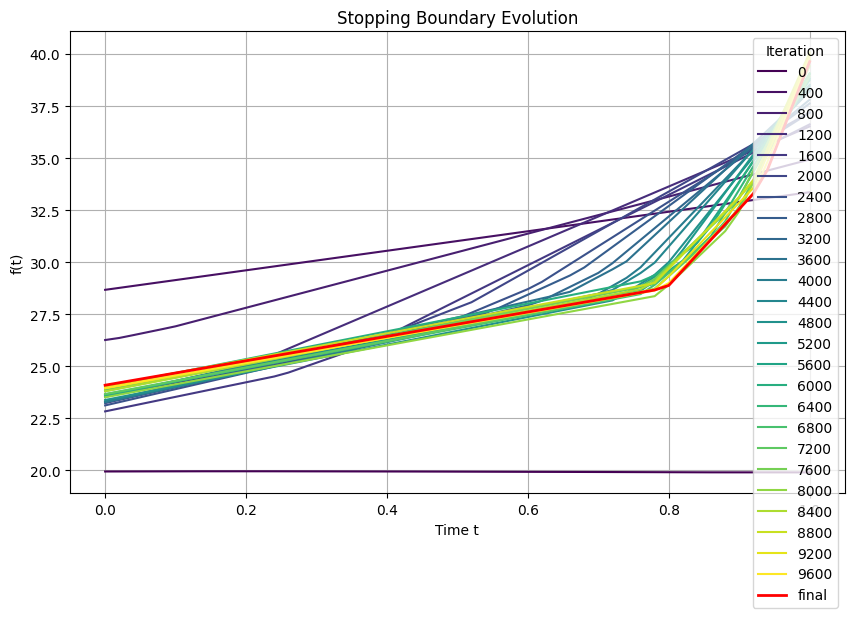

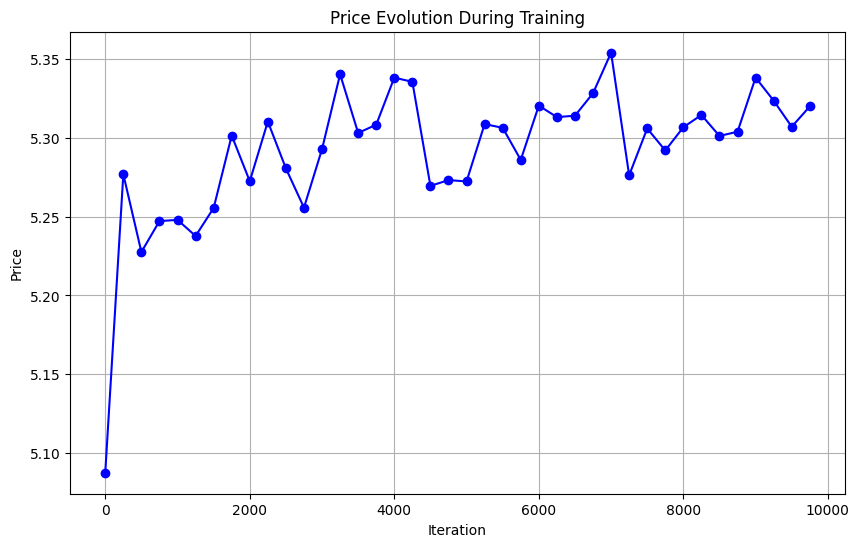

In [121]:
def simulate_paths_with_importance_sampling_random_init_S0(B, lambd):
    """
    Simulates B asset price paths under importance sampling using the Girsanov drift adjustment,
    following the paper's formulation: dS = S * ([r - sigma * lambda] dt + sigma dW)

    Args:
        B: number of paths
        lambd: float, the constant importance sampling parameter λ

    Returns:
        S: simulated paths, shape (B, len(t_grid), 1)
        Z: Radon-Nikodym derivatives Z_t^λ, shape (B, len(t_grid))
    """
    S = np.zeros((B, len(t_grid), 1), dtype=np.float32)
    Z = np.ones((B, len(t_grid)), dtype=np.float32)
    S[:, 0, 0] = np.random.uniform(0, 2*K, size=B)  # Random initial asset price
    W = np.zeros(B)  # cumulative Brownian motion

    for i in range(len(t_grid) - 1):
        z = np.random.randn(B)
        dW = np.sqrt(dt) * z
        W += dW

        drift_adjusted = r - sigma * lambd
        S[:, i + 1, 0] = S[:, i, 0] * np.exp((drift_adjusted - 0.5 * sigma**2)*dt + sigma*dW)

        # Radon–Nikodym derivative
        Z[:, i + 1] = np.exp(lambd*W - 0.5*lambd**2 * t_grid[i + 1])

    #convert to torch tensors
    Z = torch.tensor(Z, dtype=torch.float32)
    return S, Z



def alpha_fn(x):
    """
    Extracts the alpha coordinate from the state variable x.

    In this implementation for 1D option, alpha(x) corresponds to the underlying asset price,
    which is assumed to be the first (and only) feature in the state vector.
    """
    return x[:, [0]]

def Xi_fn(x):
    """Stopping boundary depends only on time"""
    return torch.zeros((x.shape[0], 1), dtype=torch.float32)


def phi_fn(t, x, r):
    """Computes the payoff function for the Put Option

    Args:
        t: Current time
        x: State variable (in this case, the stock price)
        r: Risk-free interest rate
    """
    S = x[:, [0]]
    return F.relu(K - S) * np.exp(-r * t) 

# Training parameters
eta = -1
eps = K * sigma * np.sqrt(dt)
bias0 = K / 2
latent_dim = 1
batch_size = 2048
n_iters = N_ITERS
learning_rate = 1e-3
lambd = 0.275

# Train
model_put_importance_sampling_random_init = deep_erm_training(simulate_paths_with_importance_sampling_random_init_S0,
                          alpha_fn, Xi_fn, phi_fn,
                          eta, eps, bias0,
                          latent_dim,
                          batch_size, n_iters,
                          learning_rate,
                          t_grid, r, K, lambd)

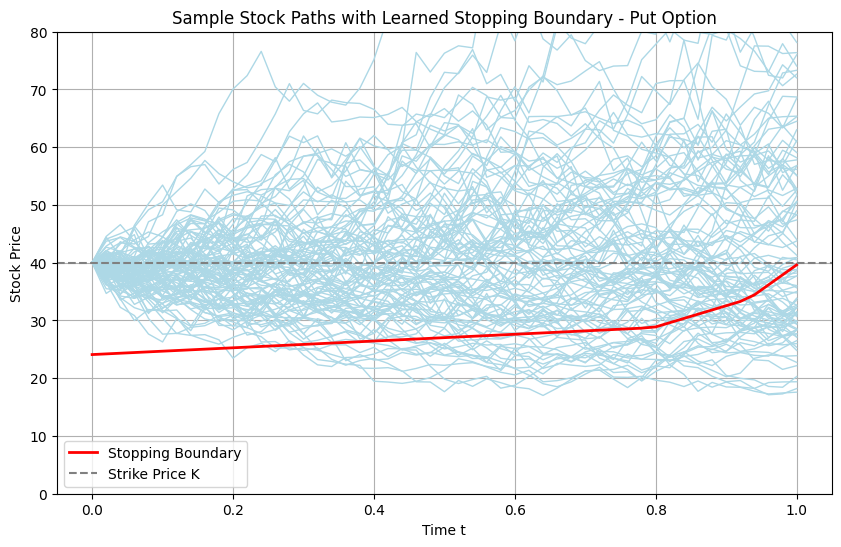

In [122]:
plot_paths_with_boundary(model_put_importance_sampling_random_init, simulate_paths, t_grid, K, num_paths=100, name="Put Option")

In [123]:
simulated_paths_price_eval = simulate_paths(100000)
final_price_with_importance_sampling_model_random_init = compute_price(model_put_importance_sampling_random_init, simulated_paths_price_eval, K)
print(f"Final price with importance sampling with random init: {final_price_with_importance_sampling_model_random_init:.6f}")


Final price with importance sampling with random init: 5.322579


### Force the neural network to output K for t=T using:  U(t) = (T-t)*V(t) + K

Training:   0%|          | 0/10000 [00:00<?, ?it/s]

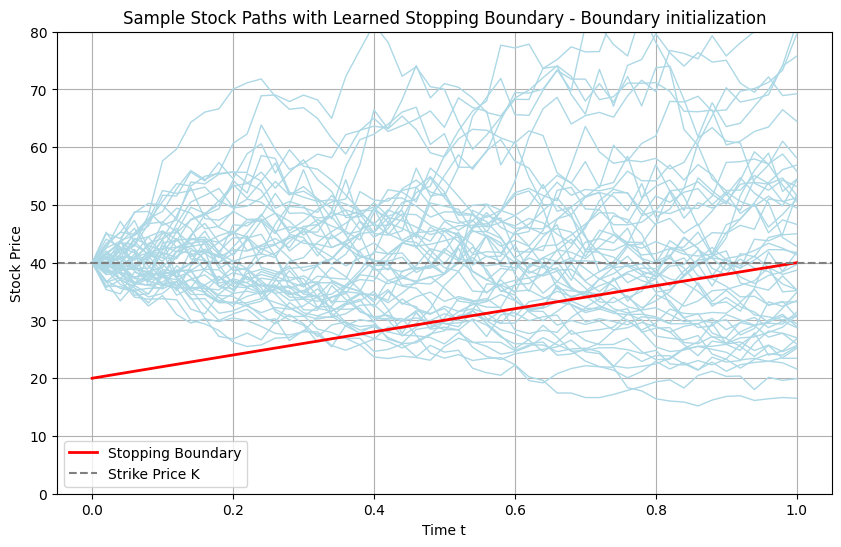

Training: 100%|██████████| 10000/10000 [16:10<00:00, 10.30it/s, loss=-5.354157]


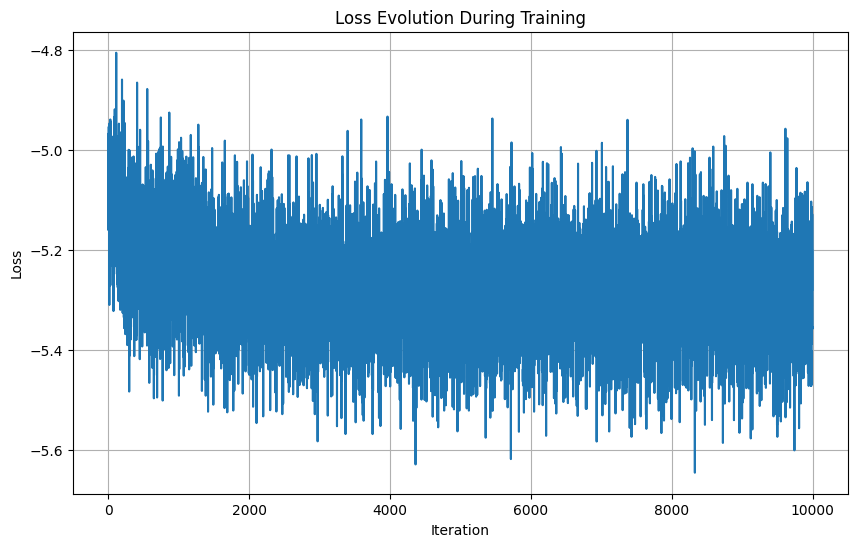

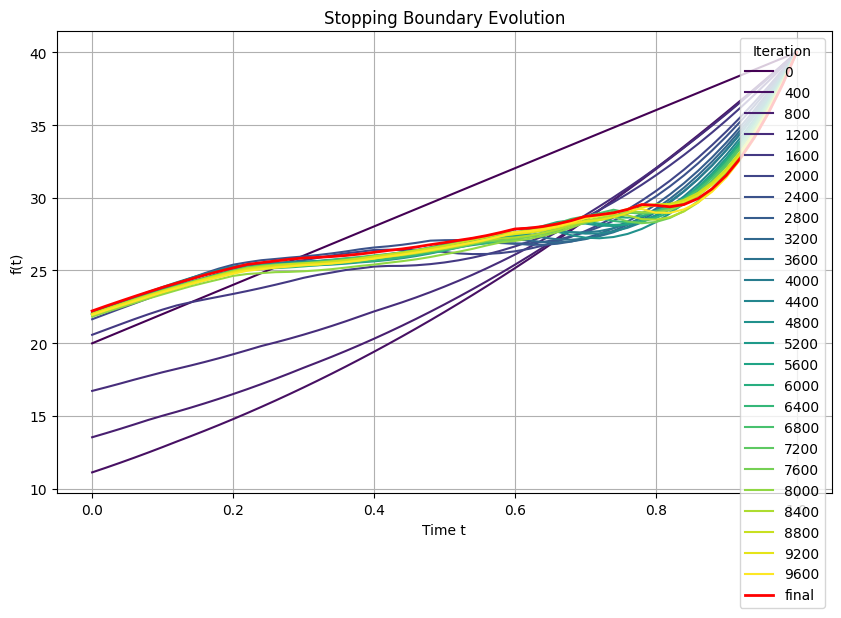

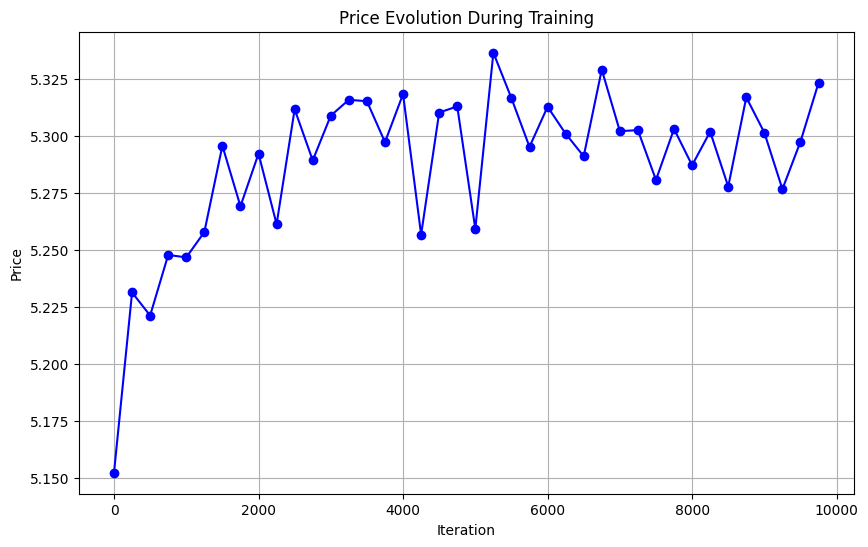

In [124]:
def simulate_paths_with_importance_sampling(B, lambd):
    """
    Simulates B asset price paths under importance sampling using the Girsanov drift adjustment,
    following the paper's formulation: dS = S * ([r - sigma * lambda] dt + sigma dW)

    Args:
        B: number of paths
        lambd: float, the constant importance sampling parameter λ

    Returns:
        S: simulated paths, shape (B, len(t_grid), 1)
        Z: Radon-Nikodym derivatives Z_t^λ, shape (B, len(t_grid))
    """
    S = np.zeros((B, len(t_grid), 1), dtype=np.float32)
    Z = np.ones((B, len(t_grid)), dtype=np.float32)
    S[:, 0, 0] = K
    W = np.zeros(B)  # cumulative Brownian motion

    for i in range(len(t_grid) - 1):
        z = np.random.randn(B)
        dW = np.sqrt(dt) * z
        W += dW

        drift_adjusted = r - sigma * lambd
        S[:, i + 1, 0] = S[:, i, 0] * np.exp((drift_adjusted - 0.5 * sigma**2)*dt + sigma*dW)

        # Radon–Nikodym derivative
        Z[:, i + 1] = np.exp(lambd*W - 0.5*lambd**2 * t_grid[i + 1])

    #convert to torch tensors
    Z = torch.tensor(Z, dtype=torch.float32)
    return S, Z



def alpha_fn(x):
    """
    Extracts the alpha coordinate from the state variable x.

    In this implementation for 1D option, alpha(x) corresponds to the underlying asset price,
    which is assumed to be the first (and only) feature in the state vector.
    """
    return x[:, [0]]

def Xi_fn(x):
    """Stopping boundary depends only on time"""
    return torch.zeros((x.shape[0], 1), dtype=torch.float32)


def phi_fn(t, x, r):
    """Computes the payoff function for the Put Option

    Args:
        t: Current time
        x: State variable (in this case, the stock price)
        r: Risk-free interest rate
    """
    S = x[:, [0]]
    return F.relu(K - S) * np.exp(-r * t) 

# Training parameters
eta = -1
eps = K * sigma * np.sqrt(dt)
bias0 = -0.5*K   #change the initial bias because otherwise the initial stopping boundary is very high due to the formula used
             #formula: f(t) = (T - t) * f(t) + K, so if bias0 is K, then f(0) = T * K, which is too high
latent_dim = 1
batch_size = 2048
learning_rate = 1e-3
lambd = 0.275
n_iters = N_ITERS

# Train
model_put_importance_sampling_and_force_end = deep_erm_training(simulate_paths_with_importance_sampling,
                          alpha_fn, Xi_fn, phi_fn,
                          eta, eps, bias0,
                          latent_dim,
                          batch_size, n_iters,
                          learning_rate,
                          t_grid, r, K, lambd, force_end_value=True, T=T)


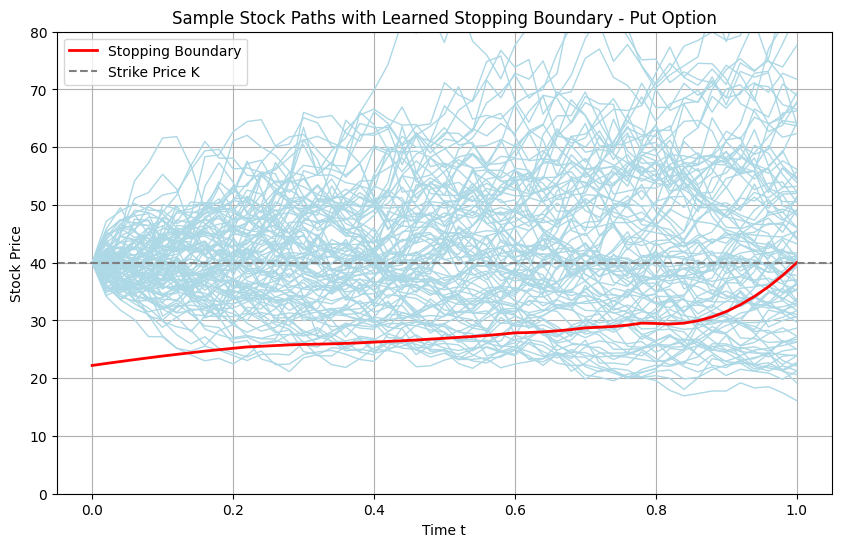

In [125]:
plot_paths_with_boundary(model_put_importance_sampling_and_force_end, simulate_paths, t_grid, K, num_paths=100, name="Put Option")

In [126]:
simulated_paths_price_eval = simulate_paths(100000)
final_price_with_importance_sampling_model_and_force_end = compute_price(model_put_importance_sampling_and_force_end, simulated_paths_price_eval, K)
print(f"Final price with importance sampling with force end value: {final_price_with_importance_sampling_model_and_force_end:.6f}")

Final price with importance sampling with force end value: 5.306112


# Comparison of the different methods

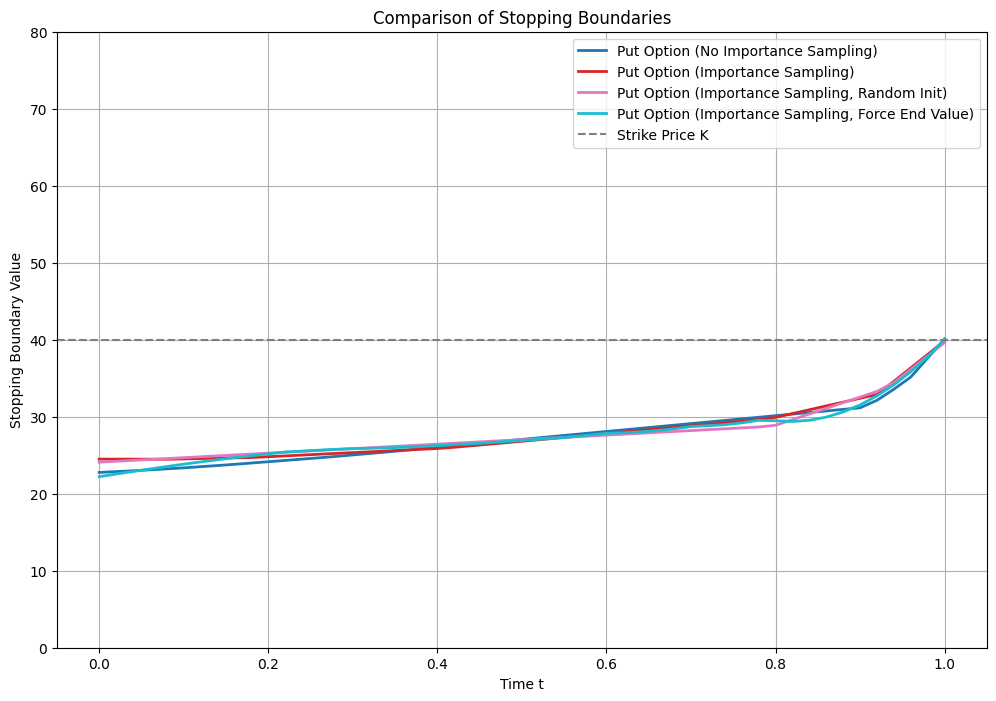

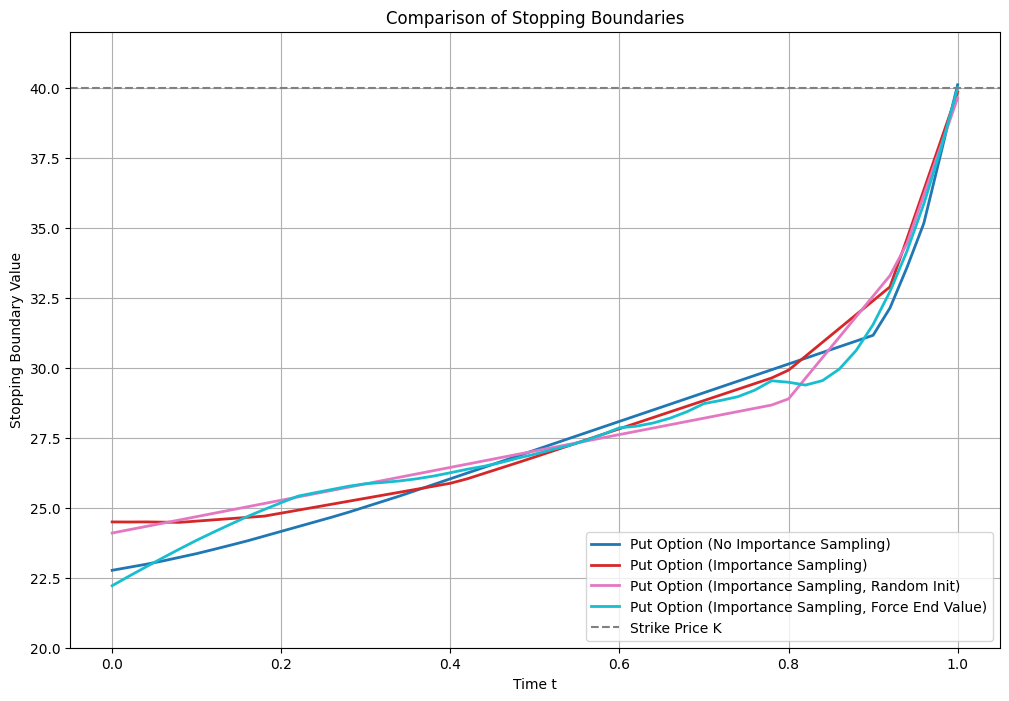

In [ ]:
def compare_stopping_boundaries(models_dict, t_grid, ylim=(0, 80)):
    """
    Plot the stopping boundaries from multiple models on the same graph for comparison.
    
    Args:
        models_dict: Dictionary with model variables as keys and names/labels as values
        t_grid: Time grid used for simulation
        ylim: Y-axis limits for the plot
    """
    plt.figure(figsize=(12, 8))
    
    t_vals = np.array(t_grid, dtype=np.float32)
    t_tensor = torch.tensor(t_vals).reshape(-1, 1)
    xi_tensor = torch.zeros_like(t_tensor)  # Xi ≡ 0
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(models_dict)))
    
    for i, (model, name) in enumerate(models_dict.items()):
        model.eval()
        with torch.no_grad():
            f_vals = model(t_tensor, xi_tensor).numpy().flatten()
            plt.plot(t_vals, f_vals, linewidth=2, color=colors[i], label=name)
    
    # Strike price horizontal line
    plt.axhline(K, color='gray', linestyle='--', linewidth=1.5, label='Strike Price K')
    
    plt.xlabel('Time t')
    plt.ylabel('Stopping Boundary Value')
    plt.title('Comparison of Stopping Boundaries')
    plt.ylim(*ylim)
    plt.legend()
    plt.grid(True)
    plt.show()



models_dict = {
    model_put: "Put Option (No Importance Sampling)",
    model_put_importance_sampling: "Put Option (Importance Sampling)",
    model_put_importance_sampling_random_init: "Put Option (Importance Sampling, Random Init)",
    model_put_importance_sampling_and_force_end: "Put Option (Importance Sampling, Force End Value)"
}

compare_stopping_boundaries(models_dict, t_grid, ylim=(0, 80))
compare_stopping_boundaries(models_dict, t_grid, ylim=(20, 42))

In [138]:

def compare_model_prices(models_dict, simulate_paths_fn, K, num_paths=100000):
    """
    Compute and print the option prices for all models in the dictionary using the same paths
    for fair comparison.
    
    Args:
        models_dict: Dictionary with model variables as keys and names/labels as values
        simulate_paths_fn: Function to simulate paths
        K: Strike price
        num_paths: Number of paths to use for price computation
    """
    print("=" * 60)
    print(f"{'Model':<40} {'Price':>10}")
    print("=" * 60)
    
    # Generate paths once to ensure all models are evaluated on the same paths
    simulated_paths = simulate_paths_fn(num_paths)
    
    for model, name in models_dict.items():
        # Use the existing compute_price function
        price = compute_price(model, simulated_paths, K)
        print(f"{name:<40} {price:>10.6f}")
    
    print("=" * 60)
    

# Run multiple price comparisons and calculate statistics
num_runs = 10
num_paths_final_comparison = 1000000
all_prices = {name: [] for _, name in models_dict.items()}

print(f"Running {num_runs} price calculations to get statistical significance...")

for i in tqdm(range(num_runs), desc="Calculating prices", unit="run"):
    # Generate paths once to ensure all models are evaluated on the same paths
    simulated_paths = simulate_paths(num_paths_final_comparison)
    
    for model, name in models_dict.items():
        # Use the existing compute_price function
        price = compute_price(model, simulated_paths, K)
        all_prices[name].append(price)

print("\n" + "=" * 80)
print(f"{'Model':<40} {'Mean Price':>10} {'Std Dev':>10}")
print("=" * 80)

for name in all_prices:
    prices = all_prices[name]
    mean_price = np.mean(prices)
    std_dev = np.std(prices)
    print(f"{name:<40} {mean_price:>10.6f} {std_dev:>10.6f}")

print("=" * 80)


Running 10 price calculations to get statistical significance...


Calculating prices: 100%|██████████| 10/10 [10:37<00:00, 63.80s/run]


Model                                    Mean Price    Std Dev
Put Option (No Importance Sampling)        5.308015   0.004545
Put Option (Importance Sampling)           5.306818   0.004425
Put Option (Importance Sampling, Random Init)   5.306569   0.004556
Put Option (Importance Sampling, Force End Value)   5.306830   0.004614
